In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
df = pd.read_csv("electricity_bill_dataset.csv")

In [4]:
df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4


In [5]:
df.shape

(45345, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45345 entries, 0 to 45344
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fan              45345 non-null  int64  
 1   Refrigerator     45345 non-null  float64
 2   AirConditioner   45345 non-null  float64
 3   Television       45345 non-null  float64
 4   Monitor          45345 non-null  float64
 5   MotorPump        45345 non-null  int64  
 6   Month            45345 non-null  int64  
 7   City             45345 non-null  str    
 8   Company          45345 non-null  str    
 9   MonthlyHours     45345 non-null  int64  
 10  TariffRate       45345 non-null  float64
 11  ElectricityBill  45345 non-null  float64
dtypes: float64(6), int64(4), str(2)
memory usage: 5.5 MB


In [7]:
df.describe()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,MonthlyHours,TariffRate,ElectricityBill
count,45345.000000,45345.000000,45345.000000,45345.000000,45345.000000,45345.0,45345.000000,45345.000000,45345.000000,45345.000000
mean,13.990694,21.705458,1.503959,12.502635,2.865057,0.0,6.488058,515.083207,8.369648,4311.771307
std,5.470816,1.672575,1.115482,5.756007,3.894933,0.0,3.443252,122.618017,0.576992,1073.886406
min,5.000000,17.000000,0.000000,3.000000,1.000000,0.0,1.000000,95.000000,7.400000,807.500000
25%,9.000000,22.000000,1.000000,7.000000,1.000000,0.0,3.000000,429.000000,7.900000,3556.800000
50%,14.000000,22.000000,2.000000,13.000000,1.000000,0.0,6.000000,515.000000,8.400000,4299.400000
75%,19.000000,23.000000,2.000000,17.000000,1.000000,0.0,9.000000,601.000000,8.900000,5038.800000
max,23.000000,23.000000,3.000000,22.000000,12.000000,0.0,12.000000,926.000000,9.300000,8286.300000


In [8]:
X = df.drop("ElectricityBill", axis=1)
y = df["ElectricityBill"]

In [9]:
X.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2


In [10]:
y.head()

0    3225.6
1    3806.4
2    3203.2
3    4370.0
4    4204.4
Name: ElectricityBill, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (36276, 11)
X_test : (9069, 11)
y_train : (36276,)
y_test : (9069,)


In [13]:
from sklearn.preprocessing import LabelEncoder

city_encoder = LabelEncoder()
company_encoder = LabelEncoder()

df["City"] = city_encoder.fit_transform(df["City"])
df["Company"] = company_encoder.fit_transform(df["Company"])

In [14]:

X = df.drop("ElectricityBill", axis=1)
y = df["ElectricityBill"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores :", cv_scores)
print("Average R2 Score :", cv_scores.mean())

Cross Validation Scores : [0.99996494 0.999949   0.99995662 0.99994263 0.99996718]
Average R2 Score : 0.9999560754575281


In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100],
    "max_depth": [10, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters :", grid_search.best_params_)
print("Best Cross Validation Score :", grid_search.best_score_)

Best Parameters : {'max_depth': None, 'n_estimators': 100}
Best Cross Validation Score : 0.9999560754575281


In [29]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 1.40143808578744
Mean Squared Error  : 27.320960403131984
Root Mean Squared Error : 5.226945609352749
R2 Score : 0.9999760220246762


In [21]:
results = pd.DataFrame({
    "Actual Bill": y_test.values,
    "Predicted Bill": y_pred
})

results.head(10)

,Actual Bill,Predicted Bill
0,5054.7,5056.0485
1,3809.2,3810.1790
2,3245.3,3246.3375
3,5728.8,5729.0100
4,4148.0,4148.3400
5,3645.6,3646.1040
6,2317.7,2321.0785
7,4100.8,4101.1960
8,2286.9,2285.3790
9,5394.4,5394.4000


In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,MonthlyHours,9.208393e-01
10,TariffRate,7.835077e-02
7,City,7.734688e-04
8,Company,8.978946e-06
0,Fan,7.578511e-06
3,Television,7.276684e-06
6,Month,6.337332e-06
2,AirConditioner,2.802839e-06
1,Refrigerator,2.661188e-06
4,Monitor,8.211887e-07


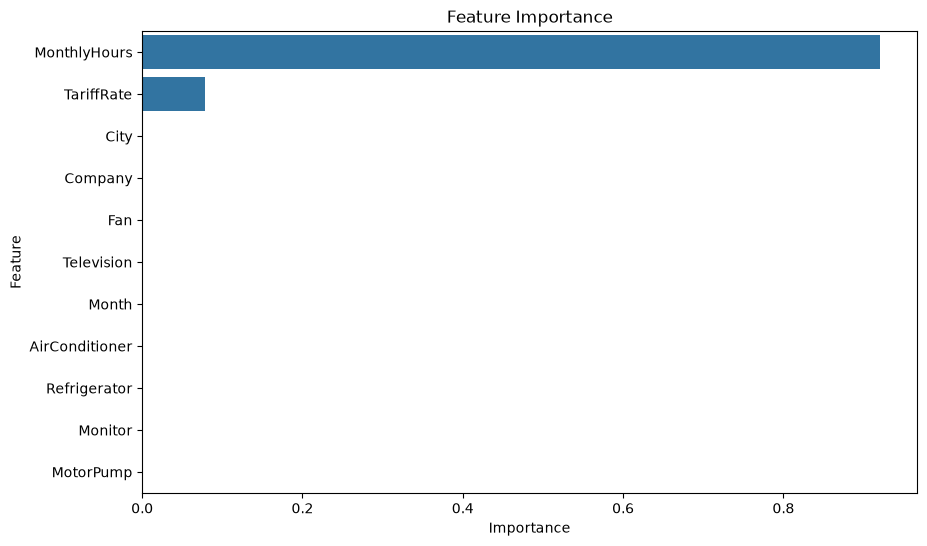

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [24]:
import joblib


joblib.dump(best_model, "random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [25]:
joblib.dump(city_encoder, "city_encoder.pkl")
joblib.dump(company_encoder, "company_encoder.pkl")

print("Encoders saved successfully!")

Encoders saved successfully!


In [26]:
sample = pd.DataFrame({
    "Fan":[15],
    "Refrigerator":[22],
    "AirConditioner":[2],
    "Television":[8],
    "Monitor":[2],
    "MotorPump":[0],
    "Month":[7],
    "City":[city_encoder.transform(["Mumbai"])[0]],
    "Company":[company_encoder.transform(["Power Grid Corp"])[0]],
    "MonthlyHours":[520],
    "TariffRate":[8.5]
})

prediction = model.predict(sample)

print("Predicted Electricity Bill : ₹", round(prediction[0],2))

Predicted Electricity Bill : ₹ 4455.01


In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

           Feature    Importance
9     MonthlyHours  9.208393e-01
10      TariffRate  7.835077e-02
7             City  7.734688e-04
8          Company  8.978946e-06
0              Fan  7.578511e-06
3       Television  7.276684e-06
6            Month  6.337332e-06
2   AirConditioner  2.802839e-06
1     Refrigerator  2.661188e-06
4          Monitor  8.211887e-07
5        MotorPump  0.000000e+00
